In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.distributions import Normal
import gymnasium as gym
import mani_skill.envs
from tqdm import tqdm
import pandas as pd

# Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    raise RuntimeError('No GPU found')

/home/users/ckw24/CS372_Robot_Arm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## PPO Class

In [2]:
class PPO():
    def __init__(self, device, env, actor_lr=1e-3, critic_lr=5e-3, clip=.2, gamma=.95, time_penalty=0,
                 actor_param_path='ppo_actor.pth', critic_param_path='ppo_critic.pth', training_data_path='Training Data.csv', 
                 load_parameters=True):
        self.obs_dim = env.observation_space.shape[1]
        self.act_dim = env.action_space.shape[1]
        self.env = env
        self.device = device
        self.clip = clip
        self.gamma = gamma
        self.time_penalty = time_penalty

        self.actor = nn.Sequential(nn.Linear(self.obs_dim, 512), 
                                   nn.ReLU(),
                                   nn.Linear(512, 512),
                                   nn.ReLU(),
                                   nn.Linear(512, 512),
                                   nn.ReLU(),
                                   nn.Linear(512, self.act_dim),
                                   nn.Tanh()).to(device)
        self.std = torch.full(size=(self.act_dim,), fill_value=0.1, device=device)
        self.critic = nn.Sequential(nn.Linear(self.obs_dim, 512), 
                                    nn.ReLU(),
                                    nn.Linear(512, 512),
                                    nn.ReLU(),
                                    nn.Linear(512, 512),
                                    nn.ReLU(),
                                    nn.Linear(512, 1)).to(device)
        if load_parameters:
            self.actor.load_state_dict(torch.load('ppo_actor.pth'))
            self.critic.load_state_dict(torch.load('ppo_critic.pth'))

        self.actor_optim = Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optim = Adam(self.critic.parameters(), lr=critic_lr)
    
    def get_action(self, obs):
        """
			Queries an action from the actor network.

			Parameters:
				obs - the observation at the current timestep as a tensor.
                      tensor of shape (batch_size, observation_dimension)

			Return:
				action - the action to take.
                         tensor of shape (batch_size, action_dimension)
				log_prob - the log probability of the selected action in the distribution
                           tensor of shape (batch_size,)
		"""
        mean = self.actor(obs)
        dist = Normal(mean, self.std)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        return action.detach(), log_prob.detach()

    def evaluate(self, obs, action):
        """
			Estimate the values of each observation, and the log probs of
			each action in the most recent batch with the most recent
			iteration of the actor network. Should be called from learn.

			Parameters:
				obs - the observations from the most recently collected batch.
				      tensor of shape (batch_size, time_steps ,observation_dimension)
				action - the actions from the most recently collected batch.
					     tensor of shape (batch_size, time_steps, action_dimension)

			Return:
				v - the predicted values of batch observations
                    tensor of shape (batch_size,)
				log_prob - the log probabilities of the action taken given obs
                           tensor of shape (batch_size,)
		"""
        v = self.critic(obs).squeeze()

        mean = self.actor(obs)
        dist = Normal(mean, self.std)
        log_prob = dist.log_prob(action).sum(dim=-1)
        
        return v, log_prob

    def run_batch(self):
        """
			Collect a batch of data from the environment. 

			Parameters:
                None

			Return:
				v - the predicted values of batch observations
                    tensor of shape (batch_size,)
				log_prob - the log probabilities of the action taken given obs
                           tensor of shape (batch_size,)
		"""
        batch_obs = []
        batch_actions = []
        batch_log_probs = []
        batch_rewards = []
        batch_mask = []

        obs, _ = env.reset()
        episode_over = False
        while not episode_over:
            batch_obs.append(obs)
            action, log_prob = model.get_action(obs)
            obs, reward, terminated, truncated, _ = self.env.step(action)
            reward -= self.time_penalty
            mask = ~(terminated | truncated)
            episode_over = not any(mask)
            batch_actions.append(action)
            batch_log_probs.append(log_prob)
            batch_rewards.append(reward)
            batch_mask.append(mask)
        
        # Stack batch data into shape (batch_size, time_steps, value(s))
        batch_obs = torch.stack(batch_obs, dim=1).to(self.device)
        batch_actions = torch.stack(batch_actions, dim=1).to(self.device)
        batch_log_probs = torch.stack(batch_log_probs, dim=1).to(self.device)
        batch_rewards = torch.stack(batch_rewards, dim=1).squeeze().to(self.device)
        batch_mask = torch.stack(batch_mask, dim=1).to(self.device)

        # Calculate returns 
        batch_timesteps = batch_rewards.shape[1]
        batch_returns = torch.zeros_like(batch_rewards)
        for i in reversed(range(batch_timesteps)):
            if i == batch_timesteps-1: 
                batch_returns[:, i] = batch_rewards[:, i]
            else: 
                batch_returns[:, i] = batch_rewards[:, i] + model.gamma*batch_returns[:, i+1]
        
        return batch_obs, batch_actions, batch_log_probs, batch_returns, batch_mask
    
    def train(self, num_batches=1_000, update_steps=5, save_freq=10, patience=5, min_num_batches=50):
        """
			Collect a batch of data from the environment. 

			Parameters:
                num_batches - total number of batches to be run
                update_steps - number of gradient ascent steps taken per batch of data
                save_freq - number of batches between saving model parameters and training data
                patience - patience condition for early stopping; set to None to disable
                min_num_batches - minimum number of batches before early stopping can occur

			Return:
				Saves model parameters and training data (as csv file)
		"""
        actor_losses = []
        critic_losses = []
        patience_count = 0
        best_actor_loss = 1e9
        for batch in tqdm(range(num_batches), desc='Training model', unit='batches'):  
            batch_obs, batch_actions, batch_log_probs, batch_returns, batch_mask = self.run_batch()
            # Determine advantage
            v, _ = self.evaluate(batch_obs, batch_actions)
            A = batch_returns - v.detach()
            A = (A-A.mean())/(A.std()+1e-10)    # Normalization helps with convergence and stability

            # Gradient ascent loop
            actor_loss = 0
            critic_loss = 0
            for _ in range(update_steps):
                # Calculate prob with new model params and determine prob ratio
                v, current_log_probs = self.evaluate(batch_obs, batch_actions)
                ratios = torch.exp(current_log_probs-batch_log_probs)
                
                # Surrogate loss function
                surr1 = ratios*A
                surr2 = torch.clamp(ratios, 1-model.clip, 1+model.clip)*A
                actor_loss = (-1*torch.min(surr1, surr2)*batch_mask).sum()/(batch_mask.sum())

                # Critic loss function
                mse = nn.MSELoss(reduction='none')
                critic_loss = (mse(v, batch_returns)*batch_mask).sum()/(batch_mask.sum())
                
                # Perform gradient steps 
                self.actor_optim.zero_grad()
                actor_loss.backward()
                self.actor_optim.step()

                self.critic_optim.zero_grad()
                critic_loss.backward()
                self.critic_optim.step()

                # Record loss values
                actor_losses.append(actor_loss.item())
                critic_losses.append(critic_loss.item())
            
            # Check for early stopping
            stop_cond = False
            if actor_losses[-1] > best_actor_loss:
                patience_count += 1
            else: 
                patience_count = 0
                best_actor_loss = actor_losses[-1]

            if patience is not None and batch+1 > min_num_batches and patience_count >= patience:
                stop_cond = True

            # Save model params and log data
            if (batch+1)%save_freq == 0 or stop_cond or batch+1 == num_batches: 
                torch.save(self.actor.state_dict(), 'ppo_actor.pth')
                torch.save(self.critic.state_dict(), 'ppo_critic.pth')
                df = pd.DataFrame({'Actor Losses': actor_losses, 'Critic losses':critic_losses})
                df.to_csv('Training Data.csv')
            
            if stop_cond: 
                print(f'Stopping early after {batch+1:d} batches')
                break

## Training Loop

In [3]:
batch_size = 64
env = gym.make(
    "PickCube-v1",
    num_envs=batch_size,
    obs_mode="state", 
    control_mode="pd_joint_delta_pos", 
    render_mode=None,
    robot_uids="so100"
)

model = PPO(device, env, load_parameters=False, actor_lr=1e-4, critic_lr=5e-3, clip=.1)
model.train(num_batches=100, patience=None)

Training model: 100%|██████████| 100/100 [01:28<00:00,  1.13batches/s]


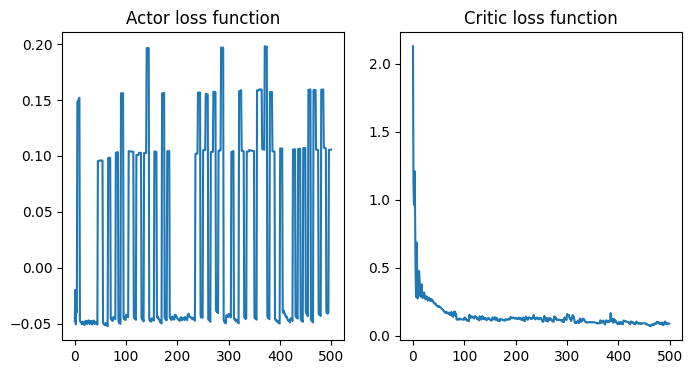

In [4]:
df = pd.read_csv('Training Data.csv')
actor_losses = df['Actor Losses'].to_numpy()
critic_losses = df['Critic losses'].to_numpy()

smoothing = 1
fig, plts = plt.subplots(1, 2, num=1, clear=True, figsize = (8, 4))
plts[0].plot(np.convolve(actor_losses, np.ones(smoothing), 'valid') / smoothing)
plts[0].set(title='Actor loss function')
plts[1].plot(np.convolve(critic_losses, np.ones(smoothing), 'valid') / smoothing)
plts[1].set(title='Critic loss function')
fig.show()

## Evaluation

In [9]:

# Run simulation 
num_envs = 8
env = gym.make(
    "PickCube-v1", # there are more tasks e.g. "PushCube-v1", "PegInsertionSide-v1", ...
    num_envs=num_envs,
    obs_mode="state", # there is also "state_dict", "rgbd", ...
    control_mode="pd_joint_delta_pos", 
    render_mode="rgb_array",
    robot_uids="so100"
)
model = PPO(device, env, load_parameters=True)

obs, _ = env.reset()
episode_over = False
frames = [env.render().cpu().numpy()]
while not episode_over:
    with torch.no_grad():
        action, _ = model.get_action(obs)
    obs, _, terminated, truncated, _ = env.step(action)
    frames.append(env.render().cpu().numpy())
    episode_over = all(terminated | truncated)
frames = np.stack(frames, axis=1)

# Create animation of simulation results
fig = plt.figure(num=2, clear=True, figsize=(9, 5))
axes = []
for i in range(num_envs):
    axes.append(fig.add_subplot(2, int(num_envs/2), i+1))
    axes[i].set(xticks=[], xticklabels=[], yticks=[], yticklabels=[])
    axes[i].imshow(frames[i][0])
fig.tight_layout()

ims = []
for i in range(frames.shape[1]):    # Loop over each timestep 
    sub_ims = []
    for j in range(frames.shape[0]):    # Loop over each arm in the batch
        sub_im = axes[j].imshow(frames[j][i], animated=True)
        sub_ims.append(sub_im)
    ims.append(sub_ims)

ani = animation.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
plt.close(fig=2)
display(HTML(ani.to_html5_video()))